# Análisis de datos: Wine Quality (Red)

Este notebook desarrolla los siguientes pasos solicitados:
1. Importar y cargar los datos del archivo CSV.
2. Realizar una limpieza y preparación básica de los datos.
3. Resumen estadístico de los datos.
4. Matriz de correlación.
5. Al menos 3 gráficos.
6. Conclusiones (mínimo 3 insights relevantes).

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('default')


## 1. Cargar los datos

In [4]:

df = pd.read_csv('winequality-red.csv', sep=';')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Limpieza y preparación básica

In [5]:

# Estandarizar nombres de columnas
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Eliminar duplicados
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Duplicados eliminados: {before - after}")

# Revisar valores faltantes
df.isna().sum()


Duplicados eliminados: 240


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## 3. Resumen estadístico

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile_acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric_acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual_sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free_sulfur_dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total_sulfur_dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
ph,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


## 4. Matriz de correlación

In [7]:

corr = df.corr(method='pearson')
corr


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
fixed_acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile_acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric_acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual_sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free_sulfur_dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total_sulfur_dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
ph,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


## 5. Gráficos

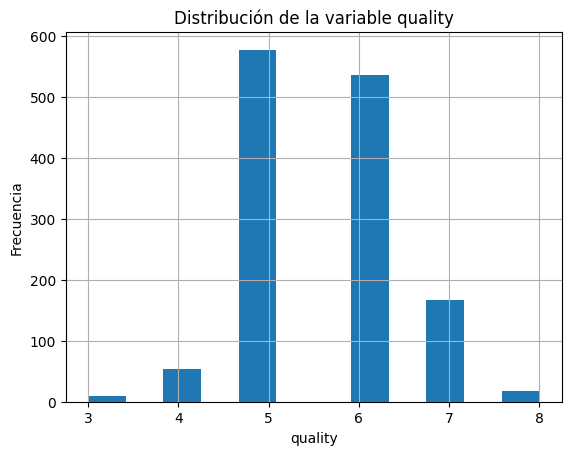

In [8]:

# Histograma de quality
df['quality'].hist(bins=12)
plt.title('Distribución de la variable quality')
plt.xlabel('quality')
plt.ylabel('Frecuencia')
plt.show()


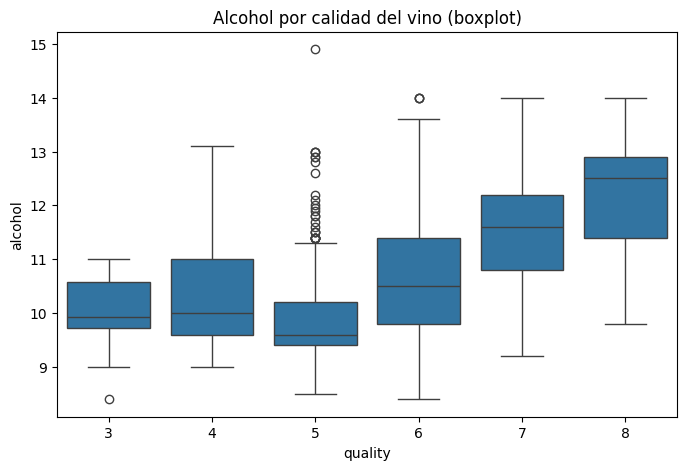

In [9]:

# Boxplot de alcohol por quality
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol por calidad del vino (boxplot)')
plt.show()


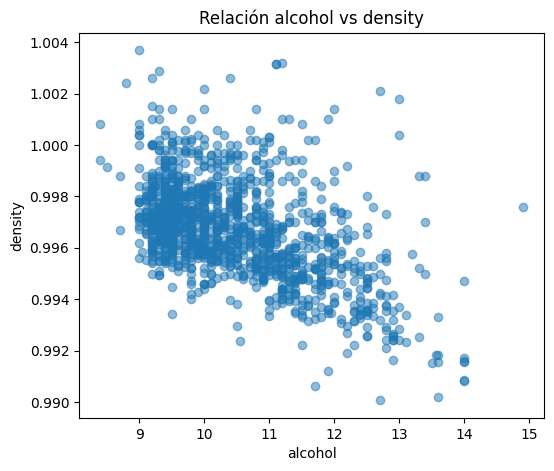

In [10]:

# Dispersión alcohol vs density
plt.figure(figsize=(6,5))
plt.scatter(df['alcohol'], df['density'], alpha=0.5)
plt.title('Relación alcohol vs density')
plt.xlabel('alcohol')
plt.ylabel('density')
plt.show()


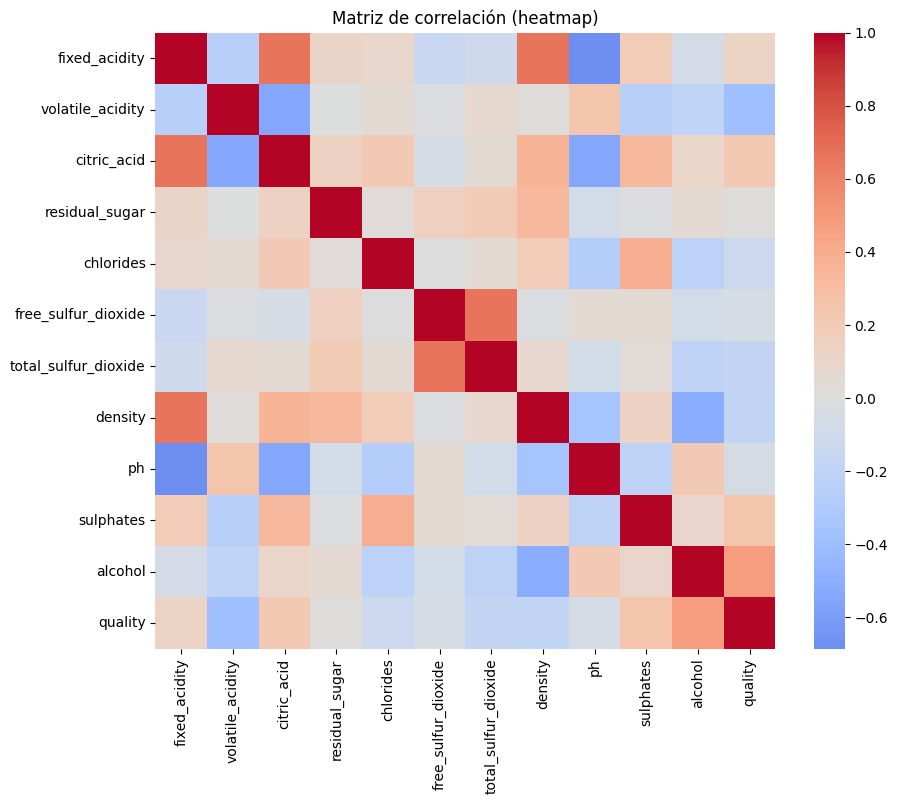

In [11]:

# Heatmap de correlaciones
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación (heatmap)')
plt.show()


## 6. Conclusiones

- **C1.** El nivel de calidad más frecuente se concentra en valores medios (5 y 6), lo que indica que la mayoría de los vinos evaluados no son de calidad extrema.
- **C2.** Se observa correlación positiva entre **alcohol**, **sulphates** y la calidad del vino; mientras que la **volatile acidity** y la **density** tienen correlación negativa.
- **C3.** La relación inversa entre **alcohol** y **density** valida fenómenos físico-químicos esperados y puede usarse como control operativo.
